## Inference

In [1]:
# Specify Image Path
image_path = '/home/bushra/Analysis_zooplankton/Data_examples/Calanoid_1/04072021_Huron_10_2mm_Rep2_AD_000002_99.tif'

### Notebook & Model Set-Up

In [2]:
import os

import torch
import torchvision.models as models
from torch.nn import functional as F

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

from helper_functions import set_seed

In [3]:
# Specify GPU
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

print(torch.cuda.get_device_name(0))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Specify other environment variables
SEED = 666
set_seed(SEED)

NVIDIA GeForce RTX 4090
Using device: cuda


In [4]:
# Paths
repository_root = os.path.abspath('')
run_name = 'final_model'

weights_path = os.path.join(repository_root, run_name, 'weights.pth')
predictions_path = os.path.join(repository_root, run_name, 'predictions.pth')
metadata_path = os.path.join(repository_root, run_name, 'environment.pth')

In [5]:
# Load Class Map and Image Transforms
metadata = torch.load(metadata_path, weights_only = False)

class_map = metadata['class_map']
class_map_rev = {v: k for k, v in class_map.items()}

image_transforms = metadata['test_loader'].dataset.dataset.image_transforms

In [6]:
# Load Model
model = models.densenet121(weights = None)
model.classifier = torch.nn.Linear(model.classifier.in_features, 14)

weights = torch.load(weights_path, map_location = device)

model.load_state_dict(weights)
model.to(device);

### Run Inference

In [7]:
# Prepare Image
image_orig = Image.open(image_path).convert('L')
image = image_transforms(image_orig)
image = image.repeat(3, 1, 1)
image = image.unsqueeze(0)
image = image.to(device, dtype = torch.float);

In [8]:
# Make Prediction
model.eval()

with torch.no_grad():
    logit = model(image)
    probs = F.softmax(logit, dim = 1)
    pred = probs.argmax(dim = 1).item()
    prob = probs[0][pred].item()

Predicted Class: Calanoid_1 (2)
Predicted Class Probability: 0.993


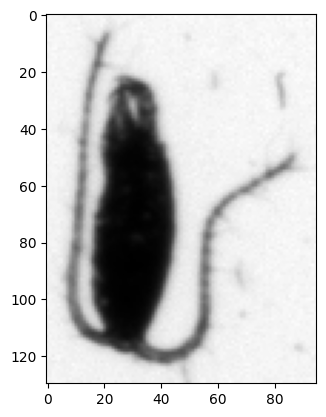

In [9]:
# Plot Image and Inference Results
print(f'Predicted Class: {class_map_rev[pred]} ({pred})')
print(f'Predicted Class Probability: {prob:.3f}')
plt.imshow(np.array(image_orig), cmap = 'gray')